In [26]:
#!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import numerical_utils as nuti

#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF
import update_config as uc
import utils as U



# The usual
from datetime import date
import numpy as np
import xarray as xr

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path

# Constants
grav=Co.grav()

importlib.reload(U)


<module 'utils' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/utils.py'>

In [2]:
ayx = U.read_in_data(fld='epwp',z=40) #'vortsrc_v01'  ) #'epwp')

{'Dst': None, 'DstVgrid': None, 'Case': 'c153_topfix_ne240pg3_FMTHIST_xic_x02', 'Archive_base': None, 'Output_abs_dir': '/glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1', 'day': 99, 'frequency': None, 'hour': 99, 'month': 7, 'year': 2004, 'Src': 'fv1x1', 'SrcVgrid': 'L93', 'Resubmit': -1, 'StepBy': 'month', 'StepN': 1, 'hsPat': 'cam.h3i'}
Will do days=[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
Will do hours=[ 0  6 12 18]
Processing /glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-01-00000.nc 
Processing /glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-01-21600.nc 
Processing /glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-01-43200.nc 

In [3]:
print ( ayx.shape)

(124, 192, 288)


In [4]:
import matplotlib.pyplot as plt


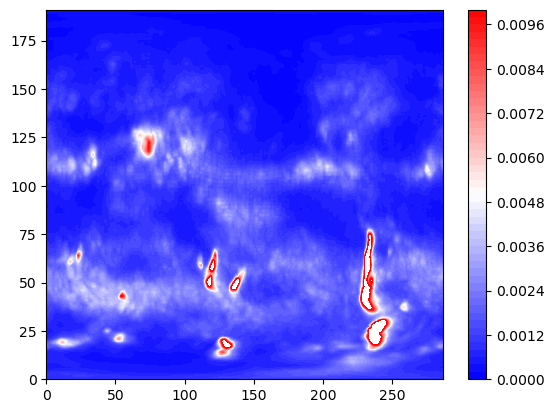

In [5]:
plt.contourf( np.mean( ayx, axis=0) , levels=np.linspace(0,.01,num=51), cmap='bwr' ) #levels=51)
plt.colorbar()

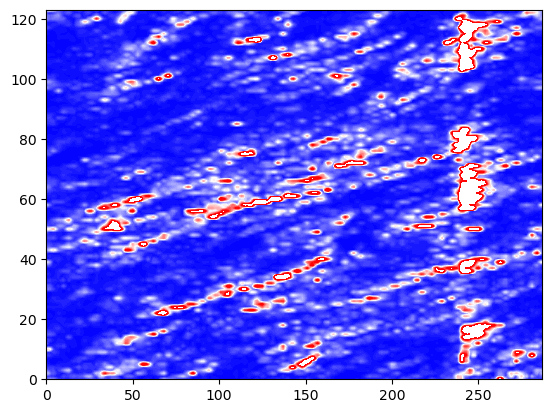

In [6]:
#plt.contourf( ayx[:,30,:] ,levels=np.linspace(-.1,.1,num=51), cmap='bwr' )

plt.contourf( ayx[:,30,:] ,levels=np.linspace(0,.01,num=51), cmap='bwr' )



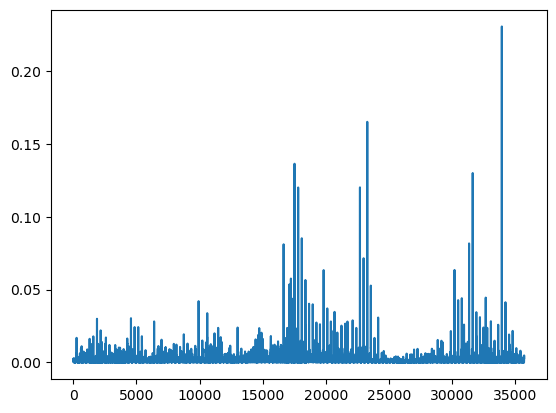

In [7]:
plt.plot( ayx[:,30,:].flatten()) 

In [11]:
nz=93
print( X.lev.values[nz-25:nz-23] )
print( X.lev.values[20] )


[498.51109676 535.42157159]
15.131370944492689


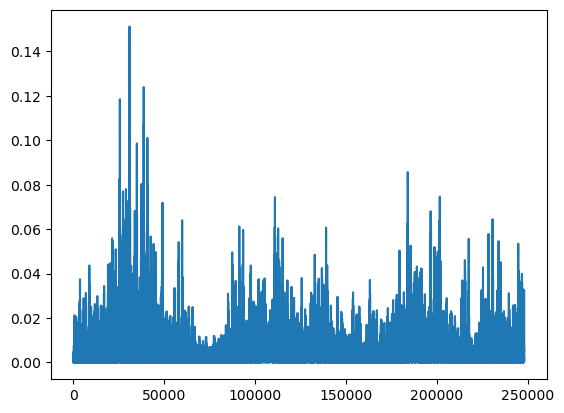

In [12]:
plt.plot( ayx[:,30:50,0:100].flatten() )

In [13]:
bins=np.linspace(0.001,0.201,num=51)
h= np.histogram(ayx[:,30:50,0:100].flatten() , bins=bins)

In [14]:
h

(array([105626,  17839,   6128,   2579,   1293,    680,    391,    229,
           188,    109,     96,     70,     43,     42,     32,     13,
            14,      9,      9,      7,      2,      4,      2,      1,
             1,      4,      4,      0,      0,      3,      1,      2,
             0,      0,      1,      1,      0,      1,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,
             0,      0]),
 array([0.001, 0.005, 0.009, 0.013, 0.017, 0.021, 0.025, 0.029, 0.033,
        0.037, 0.041, 0.045, 0.049, 0.053, 0.057, 0.061, 0.065, 0.069,
        0.073, 0.077, 0.081, 0.085, 0.089, 0.093, 0.097, 0.101, 0.105,
        0.109, 0.113, 0.117, 0.121, 0.125, 0.129, 0.133, 0.137, 0.141,
        0.145, 0.149, 0.153, 0.157, 0.161, 0.165, 0.169, 0.173, 0.177,
        0.181, 0.185, 0.189, 0.193, 0.197, 0.201]))

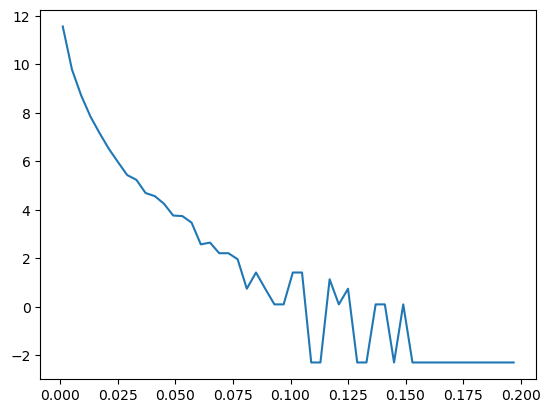

In [15]:
plt.plot(h[1][0:-1],np.log(h[0]+0.1) )


In [ ]:
f='/glade/derecho/scratch/juliob/archive/c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.2004-07-*.nc'
X=xr.open_mfdataset( f )

lon=X.lon.values
lat=X.lat.values

Lon,Lat=np.meshgrid(lon,lat)


ftopo='/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc'
Topo=xr.open_dataset( ftopo )

hs = Topo.PHIS.values/grav

In [17]:
threshold=0.01
it, iy, ix = np.where( (ayx > threshold) & (hs <0.1)) #(ayx > threshold)
mask_int = ( (ayx > threshold) & (hs <0.1)).astype(int)


In [ ]:
nps=len(ix)


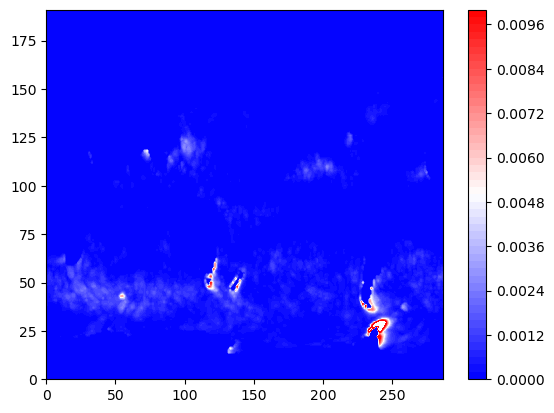

In [19]:
plt.contourf( np.mean( ayx*mask_int, axis=0) , levels=np.linspace(0,.01,num=51), cmap='bwr' ) #levels=51)
plt.colorbar()

In [21]:
%%time
uuu=XX.U.values

CPU times: user 462 ms, sys: 1.48 s, total: 1.94 s
Wall time: 2.06 s


In [22]:
uga=uuu[it,:,iy,ix]

In [23]:
uga.shape

(50254, 93)

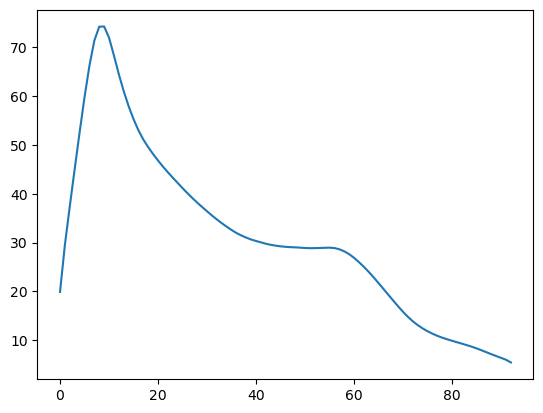

In [24]:
plt.plot(np.average(uga,axis=0))

In [27]:
zeta=U.vorticity(XX)

In [28]:
zetag=zeta[it,:,iy,ix]

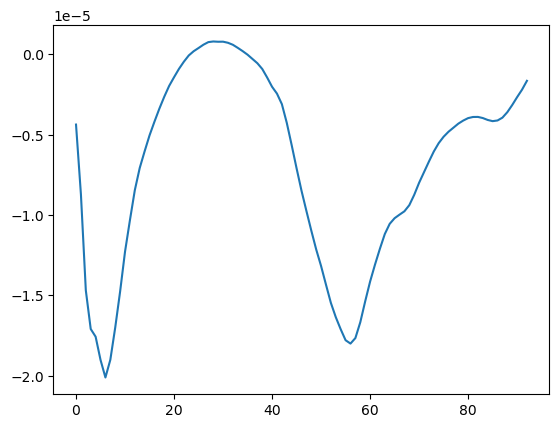

In [29]:
plt.plot(np.average(zetag,axis=0))